# TASK 2 — Unemployment Analysis with Python

## Objective

Perform exploratory data analysis on unemployment data to uncover regional
and temporal trends, with a focus on the impact of the COVID-19 pandemic
on unemployment rates in India.

## Tech Stack

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Dataset

The dataset used in this project is the "Unemployment in India" dataset
containing unemployment information for different Indian states and regions.

The dataset contains information about:

- Region
- Date
- Frequency
- Estimated Unemployment Rate (%)
- Estimated Employed
- Estimated Labour Participation Rate (%)
- Area

The dataset covers the period from May 2019 to June 2020.

In [1]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Display plots directly in Google Colab
%matplotlib inline

# Set visualization style
sns.set_style("whitegrid")

## 2. Upload Dataset

The dataset is uploaded directly to Google Colab using the file upload
function. No external download is required during notebook execution.

In [2]:
# Import Google Colab file upload utility
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India.csv


In [4]:
# Load the unemployment dataset
df = pd.read_csv("Unemployment in India.csv")

# Display the first five rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 4. Dataset Shape

The shape of the dataset tells us the number of observations and columns
available for analysis.

In [5]:
# Display number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 7)


In [6]:
# Display the original column names
print("Original Columns:")
print(df.columns.tolist())

Original Columns:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


## 6. Cleaning Column Names

The dataset contains unnecessary leading and trailing spaces in some
column names. These spaces can cause errors when accessing columns.

Therefore, the column names are cleaned before further analysis.

In [7]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

# Display cleaned column names
print("Cleaned Columns:")
print(df.columns.tolist())

Cleaned Columns:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [8]:
# Display data types of all columns
print(df.dtypes)

Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object


## 8. Missing Value Analysis

Before performing analysis, it is important to identify missing values.

Missing values can affect calculations, visualizations, and machine learning
or statistical analysis.

In [9]:
# Count missing values in every column
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [10]:
# Check completely empty rows
empty_rows = df.isnull().all(axis=1).sum()

print("Completely empty rows:", empty_rows)

Completely empty rows: 28


In [11]:
# Remove rows where every column is missing
df = df.dropna(how="all").reset_index(drop=True)

print("Shape after removing empty rows:", df.shape)

Shape after removing empty rows: (740, 7)


## 10. Date Conversion

The Date column is initially stored as text.

For time-series analysis, it must be converted into Pandas datetime format.
This allows us to extract months, years, sort dates, and perform
date-based comparisons.

In [12]:
# Remove extra spaces from date values
df["Date"] = df["Date"].astype(str).str.strip()

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

# Display the data type
print("Date data type:", df["Date"].dtype)

Date data type: datetime64[ns]


In [13]:
# List of numerical columns
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

# Convert columns to numeric values
for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Display data types after conversion
print(df.dtypes)

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object


In [14]:
# Remove rows containing missing values after type conversion
df = df.dropna().reset_index(drop=True)

# Display final shape
print("Final dataset shape:", df.shape)

# Check missing values again
print("\nMissing values:")
print(df.isnull().sum())


Final dataset shape: (740, 7)

Missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [15]:
# Display complete dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 40.6+ KB


## 14. Descriptive Statistics

Descriptive statistics provide a general understanding of the numerical
variables in the dataset.

The analysis includes:

- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [16]:
# Display descriptive statistics
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [17]:
# Count unique regions
print("Number of regions:", df["Region"].nunique())

# Display all regions
print("\nRegions:")
print(sorted(df["Region"].unique()))

Number of regions: 28

Regions:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


## 16. Area Distribution

The dataset contains observations classified as either Rural or Urban.

Understanding this distribution helps provide additional context for
unemployment analysis.

In [18]:
# Count observations by area
area_counts = df["Area"].value_counts()

print(area_counts)

Area
Urban    381
Rural    359
Name: count, dtype: int64


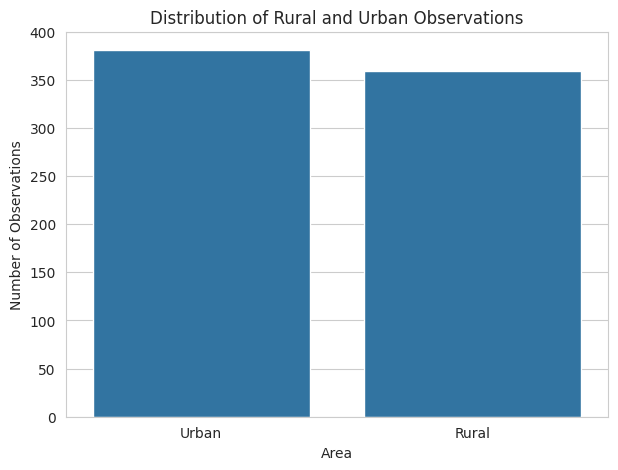

In [19]:
# Visualize Rural vs Urban observations
plt.figure(figsize=(7, 5))

sns.barplot(
    x=area_counts.index,
    y=area_counts.values
)

plt.title("Distribution of Rural and Urban Observations")
plt.xlabel("Area")
plt.ylabel("Number of Observations")

plt.show()

### Observation

The dataset contains observations from both rural and urban areas.
This allows unemployment trends to be studied across different types
of regions.

## 17. Region-wise Average Unemployment Rate

To understand regional differences, the average unemployment rate is
calculated for every state/region.

This helps identify regions that experienced relatively higher or lower
unemployment during the period covered by the dataset.

In [20]:
# Calculate average unemployment rate for each region
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

# Display results
region_avg

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


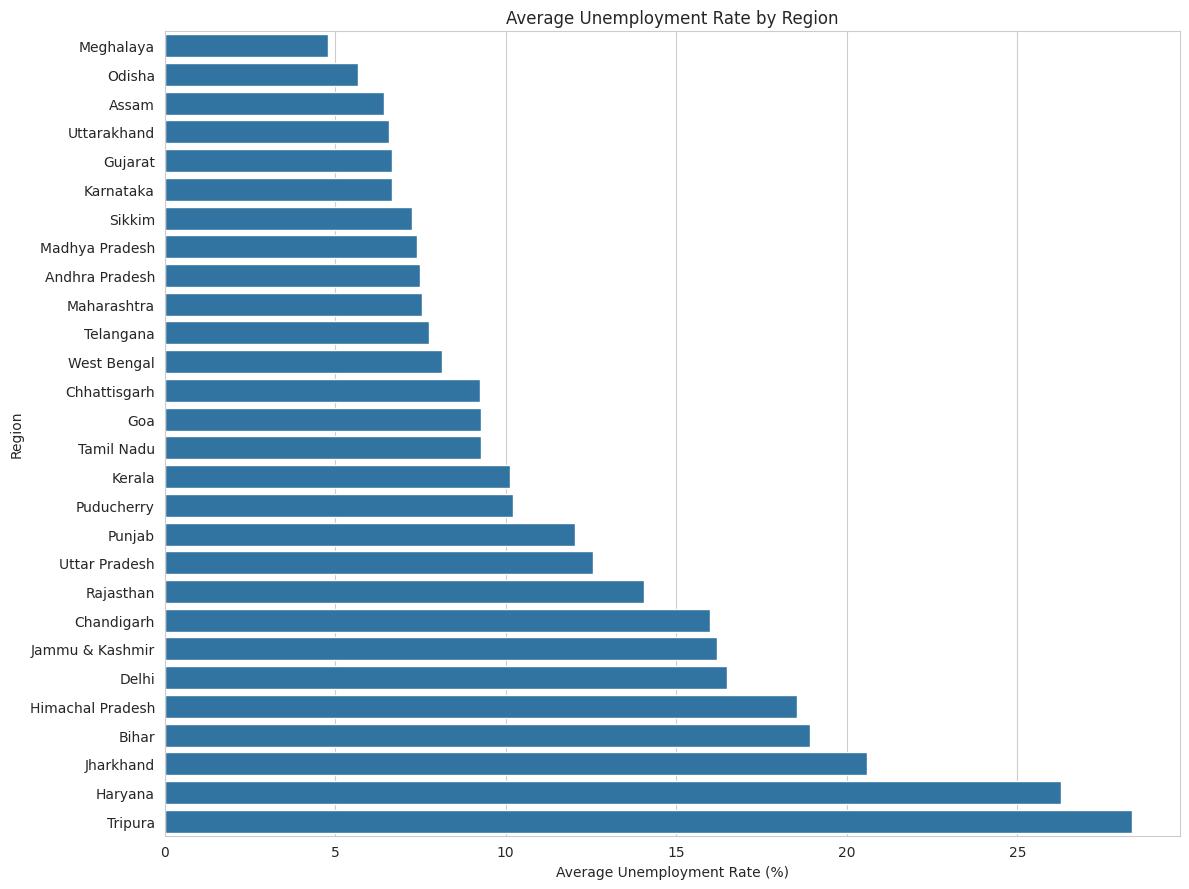

In [21]:
plt.figure(figsize=(12, 9))

# Sort values for easier visual comparison
region_avg_sorted = region_avg.sort_values()

sns.barplot(
    x=region_avg_sorted.values,
    y=region_avg_sorted.index
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Observation

There are noticeable differences in unemployment rates among Indian
regions.

Tripura and Haryana have particularly high average unemployment rates
during the period covered by this dataset, while several other regions
have comparatively lower averages.

This demonstrates that unemployment was not evenly distributed across
India.

### Observation

There are noticeable differences in unemployment rates among Indian
regions.

Tripura and Haryana have particularly high average unemployment rates
during the period covered by this dataset, while several other regions
have comparatively lower averages.

This demonstrates that unemployment was not evenly distributed across
India.

In [22]:
# Create month number and month name columns
df["Month"] = df["Date"].dt.month
df["Month Name"] = df["Date"].dt.month_name()

# Calculate average unemployment rate by month
monthly_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
)

monthly_avg

,Estimated Unemployment Rate (%)
Month,
1,9.950755
2,9.964717
3,10.700577
4,23.641569
5,16.646190
6,10.553462
7,9.033889
8,9.637925
9,9.051731


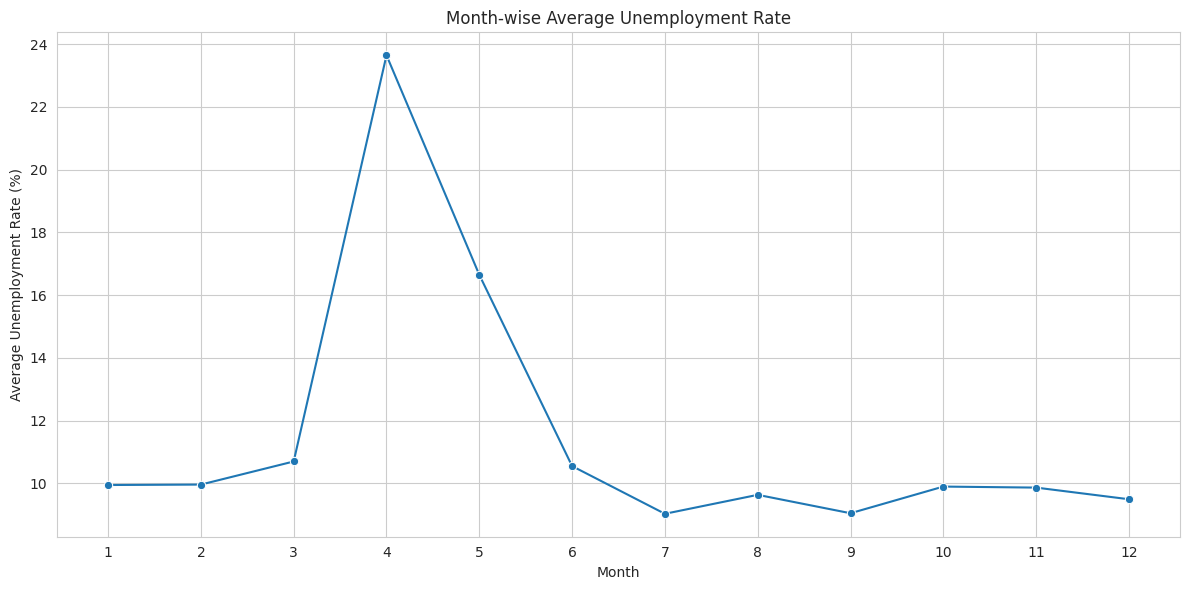

In [23]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker="o"
)

plt.title("Month-wise Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

### Observation

The month-wise analysis shows that unemployment rates changed considerably
over the observed period.

The later months, particularly the months associated with the COVID-19
period, show a substantial increase in unemployment compared with much
of the earlier period.

## 21. Time-Series Analysis

A time-series analysis is performed to observe how unemployment rates
changed over time.

Three major regions are selected for comparison:

- Haryana
- Delhi
- Maharashtra

These regions are present in the dataset and provide a useful comparison
of different unemployment patterns.

In [24]:
# Sort data by date
df = df.sort_values("Date")

# Select three regions
selected_regions = [
    "Haryana",
    "Delhi",
    "Maharashtra"
]

# Check that all selected regions exist
for region in selected_regions:
    print(
        region,
        "->",
        (df["Region"] == region).sum(),
        "observations"
    )

Haryana -> 28 observations
Delhi -> 28 observations
Maharashtra -> 28 observations


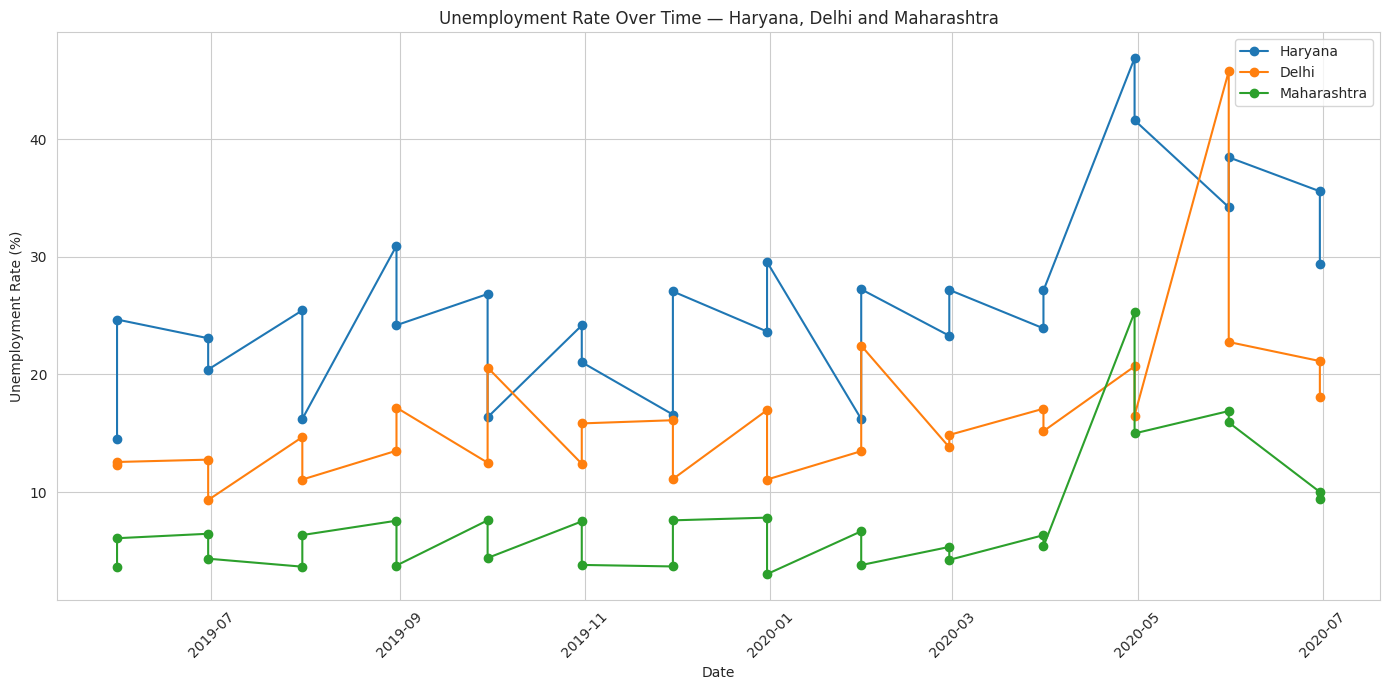

In [25]:
plt.figure(figsize=(14, 7))

# Plot unemployment rate for each selected region
for region in selected_regions:

    region_data = df[df["Region"] == region]

    plt.plot(
        region_data["Date"],
        region_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title(
    "Unemployment Rate Over Time — Haryana, Delhi and Maharashtra"
)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The time-series chart shows that unemployment rates fluctuated over the
observed period.

A particularly strong increase can be seen around the COVID-19 period.
The increase was not identical across all three regions, showing that
different states experienced different levels of employment disruption.

## 23. Top 10 Regions with Highest Average Unemployment

The top ten regions are identified by calculating their average
unemployment rate and sorting the results in descending order.

In [26]:
# Calculate top 10 regions with highest average unemployment
top_10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


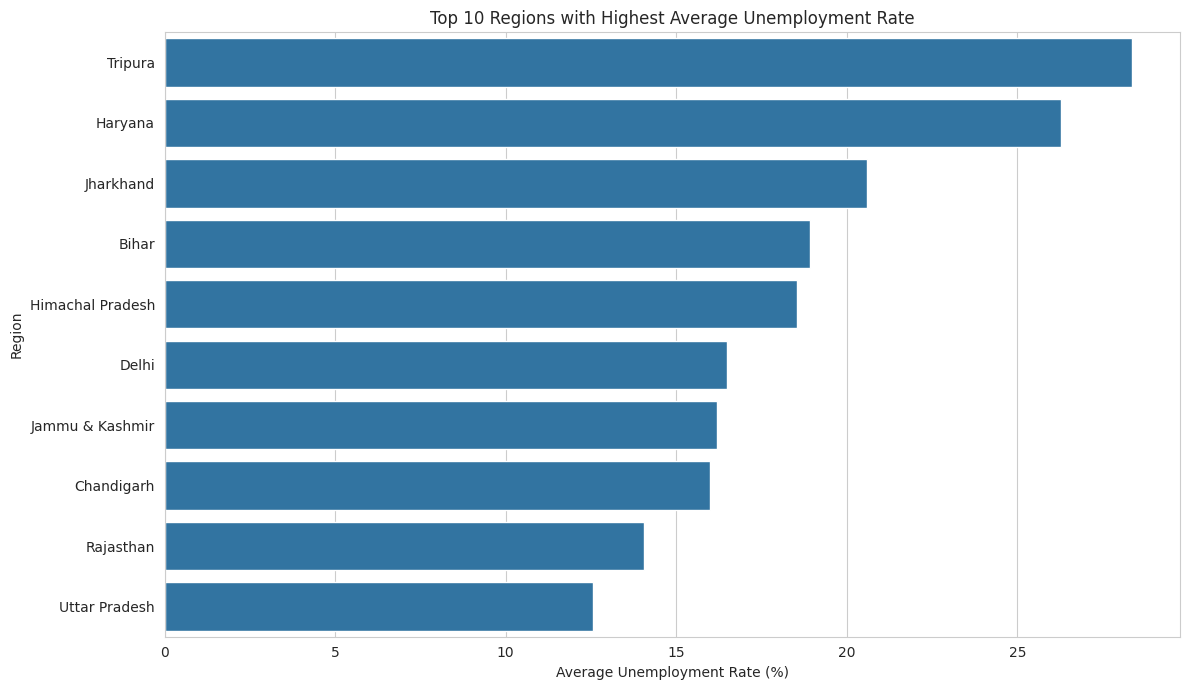

In [27]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10.values,
    y=top_10.index
)

plt.title(
    "Top 10 Regions with Highest Average Unemployment Rate"
)

plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Observation

The bar chart highlights the ten regions with the highest average
unemployment rates.

Tripura has the highest average unemployment rate in this dataset,
followed by Haryana and Jharkhand.

These differences indicate significant regional variation in unemployment
during the study period.

## 25. Correlation Analysis

Correlation analysis is used to understand the relationship between:

- Unemployment Rate
- Estimated Employed
- Labour Participation Rate

A correlation value close to +1 indicates a strong positive relationship,
while a value close to -1 indicates a strong negative relationship.
A value near 0 indicates a weak linear relationship.

In [28]:
# Select variables for correlation analysis
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


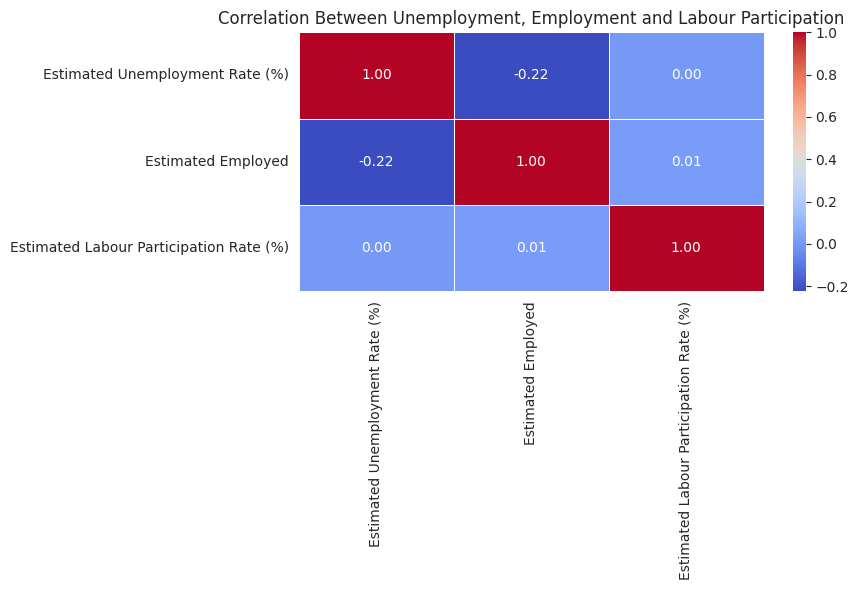

In [29]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Between Unemployment, Employment and Labour Participation"
)

plt.tight_layout()
plt.show()

### Observation

The heatmap shows the relationships among unemployment, estimated
employment, and labour participation.

The correlations help identify whether these variables tend to move
together or in opposite directions.

The relationship between unemployment rate and labour participation
provides useful insight into changes in labour-market participation,
while the employment variable reflects the estimated number of people
employed.

## 27. Pre-COVID vs COVID/Post-COVID Analysis

The dataset covers May 2019 to June 2020. Therefore, it does not contain
a long-term post-COVID period.

For this analysis:

- Pre-COVID: Before 1 March 2020
- COVID/Post-COVID period: 1 March 2020 onwards

This division allows us to compare unemployment conditions before and
during the initial COVID-19 pandemic period.

In [31]:
# Define the COVID-19 comparison date
covid_date = pd.Timestamp("2020-03-01")

# Create a period column
df["Period"] = np.where(
    df["Date"] < covid_date,
    "Pre-COVID",
    "COVID/Post-COVID"
)

# Display period counts
print(df["Period"].value_counts())

Period
Pre-COVID           536
COVID/Post-COVID    204
Name: count, dtype: int64


## 29. Period-wise Mean Comparison

The mean unemployment rate, labour participation rate, and estimated
employment are calculated separately for the two periods.

In [32]:
# Calculate mean values for each period
period_comparison = (
    df.groupby("Period")[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)"
        ]
    ]
    .mean()
)

period_comparison

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Period,,,
COVID/Post-COVID,17.774363,6.517203e+06,39.330049
Pre-COVID,9.509534,7.466028e+06,43.886119


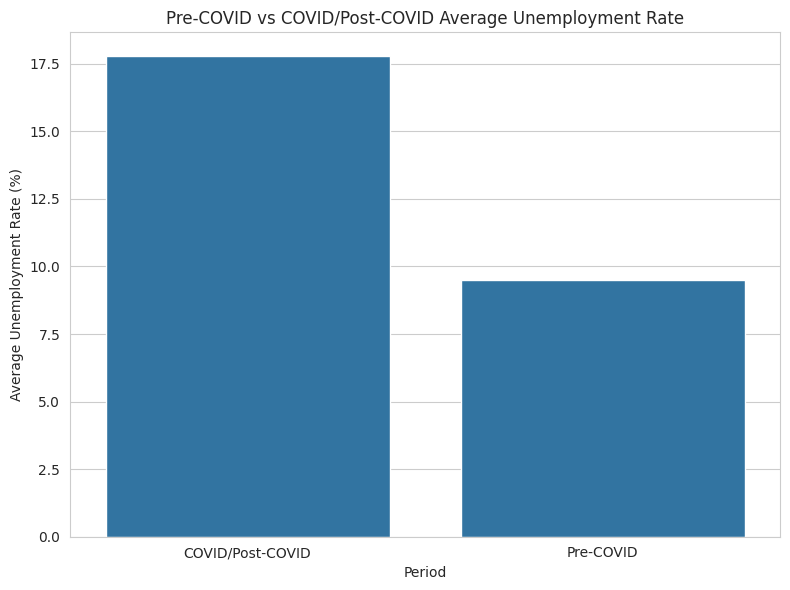

In [33]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=period_comparison.index,
    y=period_comparison[
        "Estimated Unemployment Rate (%)"
    ].values
)

plt.title(
    "Pre-COVID vs COVID/Post-COVID Average Unemployment Rate"
)

plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

### Observation

The COVID/Post-COVID period shows a substantial increase in the average
unemployment rate compared with the pre-COVID period.

This increase reflects the severe disruption caused by the COVID-19
pandemic and lockdown measures on economic activity and employment.

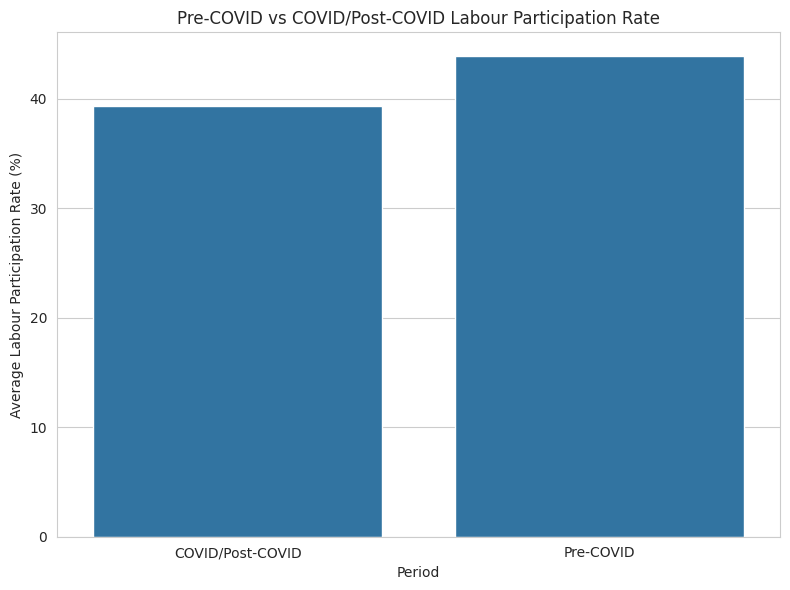

In [34]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=period_comparison.index,
    y=period_comparison[
        "Estimated Labour Participation Rate (%)"
    ].values
)

plt.title(
    "Pre-COVID vs COVID/Post-COVID Labour Participation Rate"
)

plt.xlabel("Period")
plt.ylabel("Average Labour Participation Rate (%)")

plt.tight_layout()
plt.show()

### Observation

The labour participation rate also changed between the pre-COVID and
COVID/Post-COVID periods.

The change indicates that the pandemic affected not only employment
levels but also people's participation in the labour market.

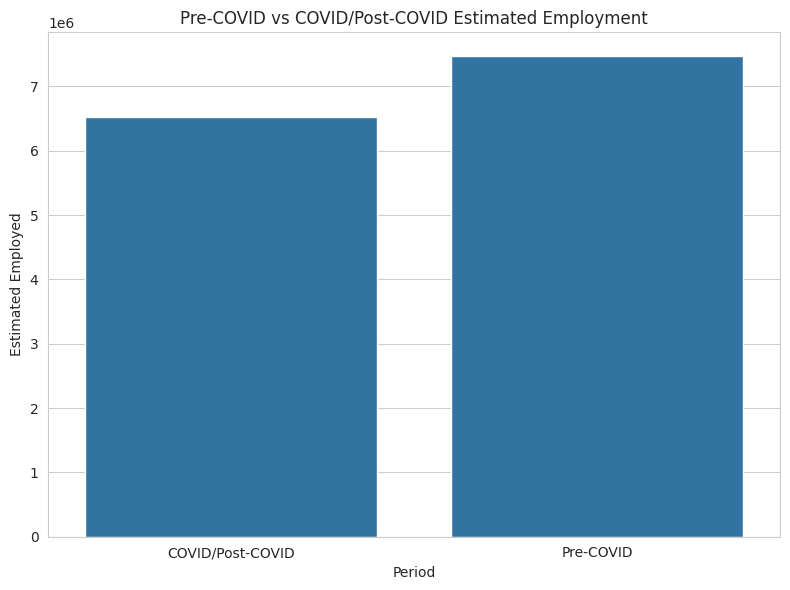

In [35]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=period_comparison.index,
    y=period_comparison[
        "Estimated Employed"
    ].values
)

plt.title(
    "Pre-COVID vs COVID/Post-COVID Estimated Employment"
)

plt.xlabel("Period")
plt.ylabel("Estimated Employed")

plt.tight_layout()
plt.show()

### Observation

The estimated employment level changed between the two periods.

The COVID-19 pandemic and lockdown restrictions caused major disruptions
to businesses and economic activity, which affected employment across
different regions of India.

## 33. Overall Unemployment Trend During COVID-19

The following chart shows India's overall average unemployment rate over
time.

A vertical line is used to indicate the beginning of the COVID/Post-COVID
comparison period.

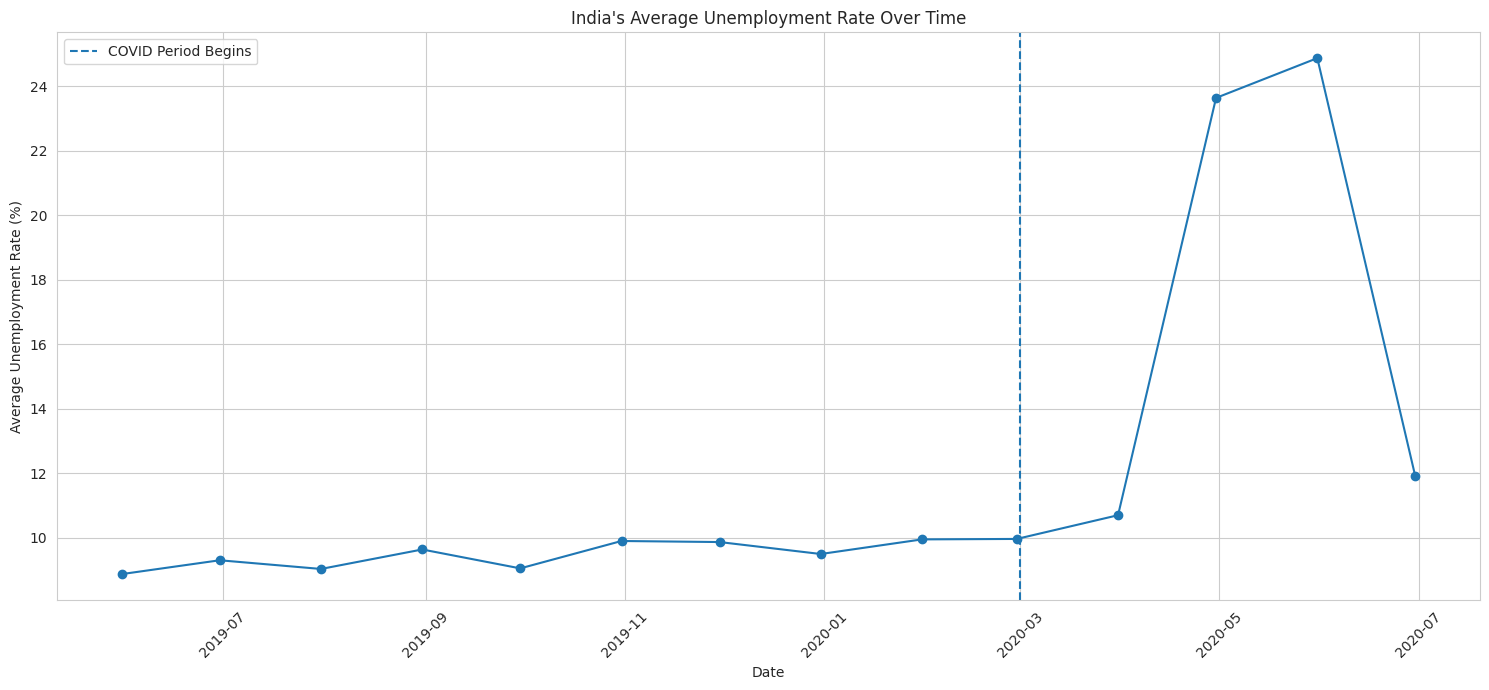

In [36]:
# Calculate overall monthly unemployment rate
overall_monthly = (
    df.groupby("Date")[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()
    .sort_index()
)

# Plot the overall trend
plt.figure(figsize=(15, 7))

plt.plot(
    overall_monthly.index,
    overall_monthly.values,
    marker="o"
)

# Mark COVID comparison date
plt.axvline(
    covid_date,
    linestyle="--",
    label="COVID Period Begins"
)

plt.title(
    "India's Average Unemployment Rate Over Time"
)

plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The overall time-series clearly shows a sharp increase in unemployment
around the beginning of the COVID-19 period.

The highest unemployment levels occur during the initial months of the
pandemic covered by the dataset, demonstrating the immediate effect of
the lockdown and economic disruption on India's labour market.

## 34. Final Summary

The following table summarizes the major changes between the pre-COVID
and COVID/Post-COVID periods.

In [37]:
# Create a clean summary table
summary = pd.DataFrame({
    "Metric": [
        "Average Unemployment Rate (%)",
        "Average Labour Participation Rate (%)",
        "Average Estimated Employment"
    ],

    "Pre-COVID": [
        period_comparison.loc[
            "Pre-COVID",
            "Estimated Unemployment Rate (%)"
        ],

        period_comparison.loc[
            "Pre-COVID",
            "Estimated Labour Participation Rate (%)"
        ],

        period_comparison.loc[
            "Pre-COVID",
            "Estimated Employed"
        ]
    ],

    "COVID/Post-COVID": [
        period_comparison.loc[
            "COVID/Post-COVID",
            "Estimated Unemployment Rate (%)"
        ],

        period_comparison.loc[
            "COVID/Post-COVID",
            "Estimated Labour Participation Rate (%)"
        ],

        period_comparison.loc[
            "COVID/Post-COVID",
            "Estimated Employed"
        ]
    ]
})

summary

,Metric,Pre-COVID,COVID/Post-COVID
0,Average Unemployment Rate (%),9.509534e+00,1.777436e+01
1,Average Labour Participation Rate (%),4.388612e+01,3.933005e+01
2,Average Estimated Employment,7.466028e+06,6.517203e+06


In [38]:
# Calculate percentage change between the two periods
percentage_change = (
    (
        period_comparison.loc["COVID/Post-COVID"]
        -
        period_comparison.loc["Pre-COVID"]
    )
    /
    period_comparison.loc["Pre-COVID"]
) * 100

print("Percentage Change:")
print(percentage_change)

Percentage Change:
Estimated Unemployment Rate (%)            86.910984
Estimated Employed                        -12.708559
Estimated Labour Participation Rate (%)   -10.381575
dtype: float64


### Observation

The percentage-change analysis provides a clearer measurement of how
unemployment, employment, and labour participation changed during the
COVID/Post-COVID period compared with the pre-COVID period.

The unemployment rate experienced the most notable change, highlighting
the severe short-term impact of the pandemic on India's labour market.

# Conclusion

This project performed an exploratory data analysis of unemployment in
India using Python, Pandas, Matplotlib, and Seaborn.

The analysis revealed significant regional and temporal differences in
unemployment rates across India.

The region-wise analysis showed that unemployment was not evenly
distributed among Indian states and regions. Tripura, Haryana, and
Jharkhand were among the regions with the highest average unemployment
rates during the period covered by the dataset.

The month-wise and time-series analyses showed considerable fluctuations
in unemployment over time. A particularly sharp increase was observed
during the initial COVID-19 pandemic period.

The correlation heatmap helped examine the relationships between
unemployment rate, estimated employment, and labour participation rate.

The comparison between the pre-COVID and COVID/Post-COVID periods showed
a substantial increase in unemployment during the pandemic period.
Changes were also observed in estimated employment and labour force
participation.

Overall, the analysis demonstrates how exploratory data analysis and
data visualization can be used to identify important economic trends
and understand the impact of major events such as the COVID-19 pandemic
on employment in India.